# **HOTEL BOOKING CANCELLATION**

# Problem

Our project focuses on developing a predictive model to identify whether a hotel booking is likely to be canceled. This is a critical task for hotels, as cancellations significantly impact both revenue and operational strategies. The dataset includes numerous features related to bookings, such as lead time, deposit type, and special requests, which contribute to the model's complexity. A significant part of the challenge lies in preprocessing the data, which involves steps such as feature selection and engineering, addressing missing values, and managing data noise. Furthermore, we will train multiple models, assess their performance using appropriate evaluation metrics, and analyze key features to understand their influence on hotel booking cancellations.

# Objectives:



- **Dataset Exploration**: Examine the dataset to understand its structure, including basic details and summary statistics for both numerical and categorical variables.  
- **Data Preprocessing**:  
  - Perform feature selection and engineering to identify key variables.  
  - Address missing data effectively.  
  - Manage and reduce noisy data.  
  - Encode categorical variables into a suitable format for modeling.  
- **Model Development**:  
  - Build and optimize classification models such as Decision Trees, Random Forest, and XGBoost.  
  - Focus on maximizing the F1-score for class 1 to ensure accurate identification of booking cancellations.  
- **Model Evaluation and Comparison**: Assess the models' performance using metrics like accuracy, precision, recall, F1-score, and AUC to determine their effectiveness.  
- **Feature Importance Analysis**: Identify and interpret the most influential features contributing to model predictions.

Step - 1 Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


In [ ]:
# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': 'lightblue'}, style='darkgrid')

Step 2 - Loading Dataset

In [ ]:
df = pd.read_csv('/content/hotel_booking.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Step 3 - EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print(missing_values)

# Alternatively, calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


In [ ]:
categorical_columns_semantics = [
    'hotel',
    'is_canceled',
    'arrival_date_year',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'agent',
    'company',
    'customer_type',
    'reservation_status',
    'name',
    'email',
    'phone-number',
    'credit_card'
]

# Convert specified columns to string (object) data type if they exist in the DataFrame
df[categorical_columns_semantics] = df[categorical_columns_semantics].astype(str, errors='ignore')

# Verify the changes in data types
print(df.dtypes)


hotel                              object
is_canceled                        object
lead_time                           int64
arrival_date_year                  object
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                  object
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

Summary Statistics

In [ ]:
#summary for numerical data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0


In [ ]:
#summary for categorical data
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
is_canceled,119390,2,0,75166
arrival_date_year,119390,3,2016,56707
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,119390,178,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
is_repeated_guest,119390,2,0,115580
reserved_room_type,119390,10,A,85994


In [ ]:
df = pd.read_csv("/content/hotel_booking.csv")


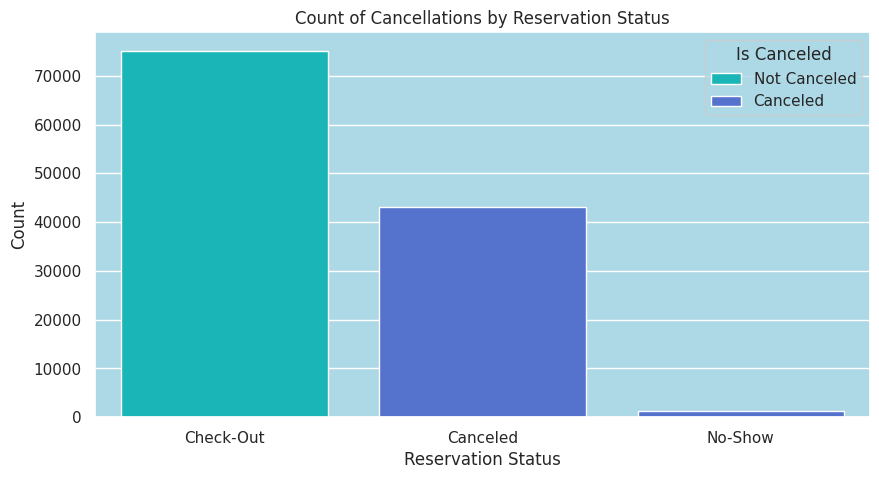

In [ ]:
# Bivariate bar plot of 'is_canceled' vs 'reservation_status' with specified colors
plt.figure(figsize=(10, 5))
sns.countplot(x='reservation_status', hue='is_canceled', data=df, palette=['darkturquoise', 'royalblue'])
plt.title('Count of Cancellations by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

In [ ]:
df.groupby('reservation_status')['is_canceled'].mean()

,is_canceled
reservation_status,
Canceled,1.0
Check-Out,0.0
No-Show,1.0


Inference: The plot clearly shows that all bookings with a reservation_status of "Canceled" or "No-Show" are marked as canceled (is_canceled = 1), while those with a reservation_status of "Check-Out" are not canceled (is_canceled = 0). This demonstrates a direct correlation between the reservation_status feature and the is_canceled target variable. Including this feature in the model would lead to data leakage, making it necessary to exclude reservation_status before training the model.

In [ ]:
# Drop the `reservation_status` feature

df = df.drop(['reservation_status'], axis=1)

In [ ]:
# Convert 'reservation_status_date' to datetime format
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Combine arrival date columns into a single datetime column and calculate the difference in days
df['reservation_status_days_difference'] = (
    df['reservation_status_date'] -
    pd.to_datetime(df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']]
                   .astype(str).agg('-'.join, axis=1))
).dt.days

# Display the result
df[['reservation_status_days_difference']].head()


,reservation_status_days_difference
0,0
1,0
2,1
3,1
4,2


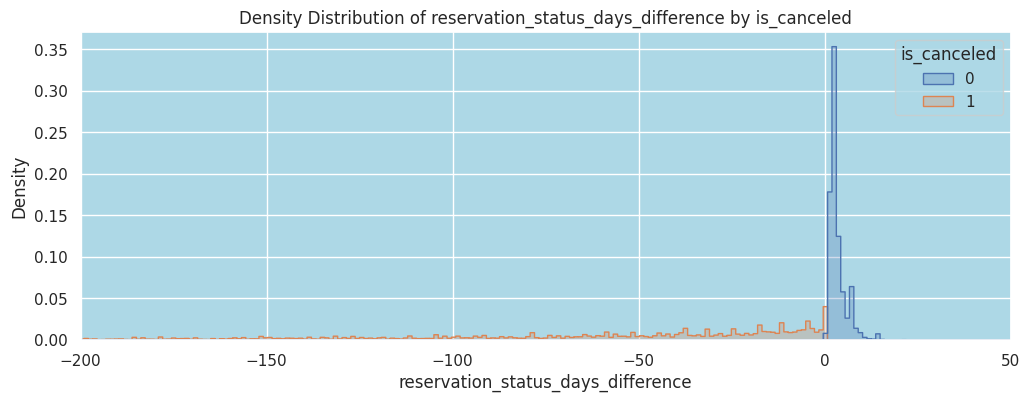

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.histplot(
    data=df,
    x="reservation_status_days_difference",
    hue="is_canceled",
    element="step",
    stat="density",
    common_norm=False
)
plt.title('Density Distribution of reservation_status_days_difference by is_canceled')
plt.xlim(-200,50)  # Set the x-axis range
plt.show()



In [ ]:
# For positive values of reservation_status_days_difference
print("Distribution of 'is_canceled' when 'reservation_status_days_difference' is positive:\n")
print(df[df['reservation_status_days_difference'] > 0]['is_canceled'].value_counts())

# For negative values of reservation_status_days_difference
print("\n" + "-"*85)
print("\nDistribution of 'is_canceled' when 'reservation_status_days_difference' is negative:\n")
print(df[df['reservation_status_days_difference'] < 0]['is_canceled'].value_counts())

Distribution of 'is_canceled' when 'reservation_status_days_difference' is positive:

is_canceled
0    74460
Name: count, dtype: int64

-------------------------------------------------------------------------------------

Distribution of 'is_canceled' when 'reservation_status_days_difference' is negative:

is_canceled
1    42137
Name: count, dtype: int64


Positive values indicate that the reservation status was updated after the guest's arrival date. In these cases, where is_canceled is always 0, it implies that the bookings were not canceled, and the status was updated (e.g., to "Check-Out") following the guest's arrival.
Negative values, on the other hand, indicate that the reservation status was updated prior to the arrival date. Here, is_canceled is consistently 1, suggesting that these bookings were canceled before the arrival date.

In [ ]:
#drop irrelevant variables

# Drop the 'reservation_status_date' and 'reservation_status_days_difference' and 'assigned_room_type' columns
df = df.drop(['reservation_status_date', 'reservation_status_days_difference', 'assigned_room_type'], axis=1)





In [ ]:
df['arrival_date_year'].value_counts()

,count
arrival_date_year,
2016,56707
2017,40687
2015,21996


In [ ]:
# Drop the `arrival_date_year` feature
df = df.drop(['arrival_date_year'], axis=1)

In [ ]:
# Create a dataframe with the number of unique categories and missing values for each high-cardinality feature
high_cardinality_features = ['country', 'agent', 'company', 'name', 'email', 'phone-number', 'credit_card']
unique_categories = df[high_cardinality_features].nunique()
missing_values = df[high_cardinality_features].isnull().sum()

# Combine the two series into a single dataframe
high_cardinality_df = pd.DataFrame({'Unique_Categories': unique_categories, 'Missing_Values': missing_values})

high_cardinality_df

,Unique_Categories,Missing_Values
country,177,488
agent,333,16340
company,352,112593
name,81503,0
email,115889,0
phone-number,119390,0
credit_card,9000,0


In [ ]:
# Feature Engineering for 'name' feature
# Create a new feature representing the number of bookings made by each guest (based on the name)
df['number_of_bookings'] = df.groupby('name')['name'].transform('count')

# Drop the original 'name' feature and other high-cardinality features
df = df.drop(['name', 'country', 'agent', 'company', 'email', 'phone-number', 'credit_card'], axis=1)

df[['number_of_bookings']].head()

,number_of_bookings
0,1
1,2
2,3
3,1
4,1


In [ ]:
# Calculate and display the percentage of missing values for columns with missing data
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage[missing_values_percentage > 0]


,0
children,0.00335


In [ ]:
# Impute missing values in 'children' column with 0 and verify
missing_children_count = df['children'].fillna(0, inplace=True) or df['children'].isnull().sum()
missing_children_count


0

In [ ]:
# Define conditions for noisy data
noisy_data = {
    'adr': df.query('adr < 0'),
    'adults': df.query('adults == 0'),
    'children': df.query('children == 10'),
    'babies': df.query('babies == 10'),
}

# Count noisy data for each condition
noisy_data_count = {key: len(data) for key, data in noisy_data.items()}
noisy_data_count


{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [ ]:
# Handle noisy data
df['adr'] = df['adr'].apply(lambda x: df['adr'].median() if x < 0 else x)  # Replace negative adr with median
df = df.query('adults != 0 & children != 10 & babies != 10')              # Remove irrelevant rows
df.reset_index(drop=True, inplace=True)                                   # Reset the index

# Verify that noisy data has been handled
noisy_data_handled = {
    'adr': df.query('adr < 0'),
    'adults': df.query('adults == 0'),
    'children': df.query('children == 10'),
    'babies': df.query('babies == 10'),
}

noisy_data_handled_count = {key: len(data) for key, data in noisy_data_handled.items()}
noisy_data_handled_count


{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

In [ ]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64
children,float64


In [ ]:
# Convert 'arrival_date_month' to numerical values
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = df['arrival_date_month'].apply(lambda x: months.index(x) + 1)

# One-hot encode the specified columns
one_hot_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118985 entries, 0 to 118984
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     118985 non-null  int64  
 1   lead_time                       118985 non-null  int64  
 2   arrival_date_month              118985 non-null  int64  
 3   arrival_date_week_number        118985 non-null  int64  
 4   arrival_date_day_of_month       118985 non-null  int64  
 5   stays_in_weekend_nights         118985 non-null  int64  
 6   stays_in_week_nights            118985 non-null  int64  
 7   adults                          118985 non-null  int64  
 8   children                        118985 non-null  float64
 9   babies                          118985 non-null  int64  
 10  is_repeated_guest               118985 non-null  int64  
 11  previous_cancellations          118985 non-null  int64  
 12  previous_booking

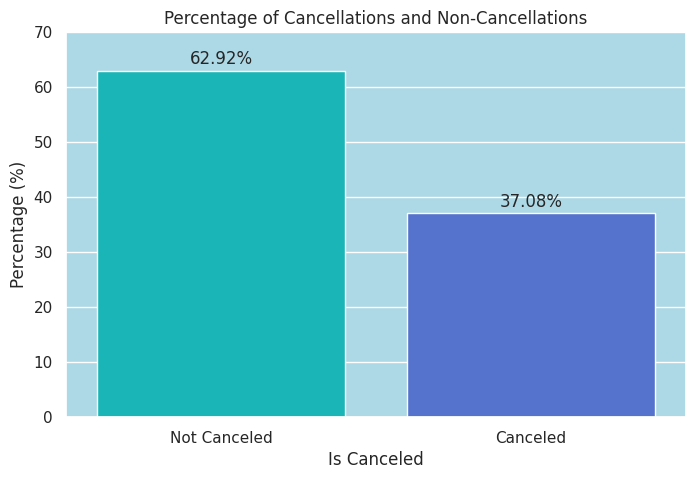

In [ ]:
# Calculating the percentage of each class
percentage = df['is_canceled'].value_counts(normalize=True) * 100

# Plotting the percentage of each class
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=percentage.index, y=percentage, palette=['darkturquoise', 'royalblue'])
plt.title('Percentage of Cancellations and Non-Cancellations')
plt.xlabel('Is Canceled')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled'])
plt.yticks(ticks=range(0,80,10))

# Displaying the percentage on the bars
for i, p in enumerate(percentage):
    ax.text(i, p + 0.5, f'{p:.2f}%', ha='center', va='bottom')

plt.show()

In [ ]:
# Define the features (X) and the output labels (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']


In [ ]:
np.asarray(df.columns)

array(['is_canceled', 'lead_time', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
       'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'number_of_bookings', 'hotel_Resort Hotel', 'meal_FB', 'meal_HB',
       'meal_SC', 'meal_Undefined', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'market_segment_Undefined',
       'distribution_channel_Direct', 'distribution_channel_GDS',
       'distribution_channel_TA/TO', 'distribution_channel_Undefined',
       'reserved_room_type_B', 'reserved_room_type_C',
       'reserved_room_type_D', 'reserved_room_type

Train and Test split

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Evaluate the model (example: accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression: {accuracy}")

# You can add other evaluation metrics here, such as:
#The following lines were incorrectly indented, causing the error.
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

Accuracy of Logistic Regression: 0.788376686136908
              precision    recall  f1-score   support

           0       0.79      0.90      0.84     14917
           1       0.78      0.61      0.68      8880

    accuracy                           0.79     23797
   macro avg       0.79      0.75      0.76     23797
weighted avg       0.79      0.79      0.78     23797



Decision Tree Model Building

In [ ]:
#loading our usual libraries
!pip install dmba shap scikit-plot
!pip install shap scikit-plot
!pip install scipy==1.7.3


# Imports
import shap
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, \
                            BaggingClassifier, BaggingRegressor, \
                            GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, \
                            classification_report, precision_score, \
                            accuracy_score, roc_curve, roc_auc_score
from dmba import regressionSummary, exhaustive_search, adjusted_r2_score, AIC_score, BIC_score
from dmba import classificationSummary, gainsChart, liftChart, plotDecisionTree
import matplotlib.pylab as plt
import seaborn as sns

# Matplotlib and seaborn configuration
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2, 'font.family': [u'times']})

plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('font', size=12)
plt.rc('figure', figsize=(6, 5))



In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# Define the base Decision Tree model
dt_base = DecisionTreeClassifier(random_state=0)

def optimize_hyperparameters(model, param_grid, X_train, y_train, metric='f1', folds=5):
    """
    Optimize hyperparameters for a given classifier using GridSearchCV and StratifiedKFold cross-validation.
    Selects the best hyperparameters based on the specified scoring metric and returns the tuned model.
    """
    # Set up cross-validation strategy
    cross_val = StratifiedKFold(n_splits=folds, shuffle=True, random_state=0)

    # Set up GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cross_val,
                               scoring=metric, n_jobs=-1)

    # Fit GridSearchCV on the training data
    grid_search.fit(X_train, y_train)

    # Extract the best parameters and model
    return grid_search.best_estimator_, grid_search.best_params_


In [ ]:
#for plotting decision trees
import pydotplus as pplus
import graphviz
from IPython.display import Image
from six import StringIO
# if not found: ! pip install six

#for modeling with decision trees
from sklearn.tree import export_graphviz

In [ ]:
def print_tree(estimator, features, class_names=None, filled=True):
    tree = estimator
    names = features
    color = filled
    classn = class_names

    dot_data = StringIO()
    export_graphviz(estimator, out_file=dot_data, feature_names=features,\
                    class_names=classn, filled=filled)
    graph = pplus.graph_from_dot_data(dot_data.getvalue())
    return(graph)

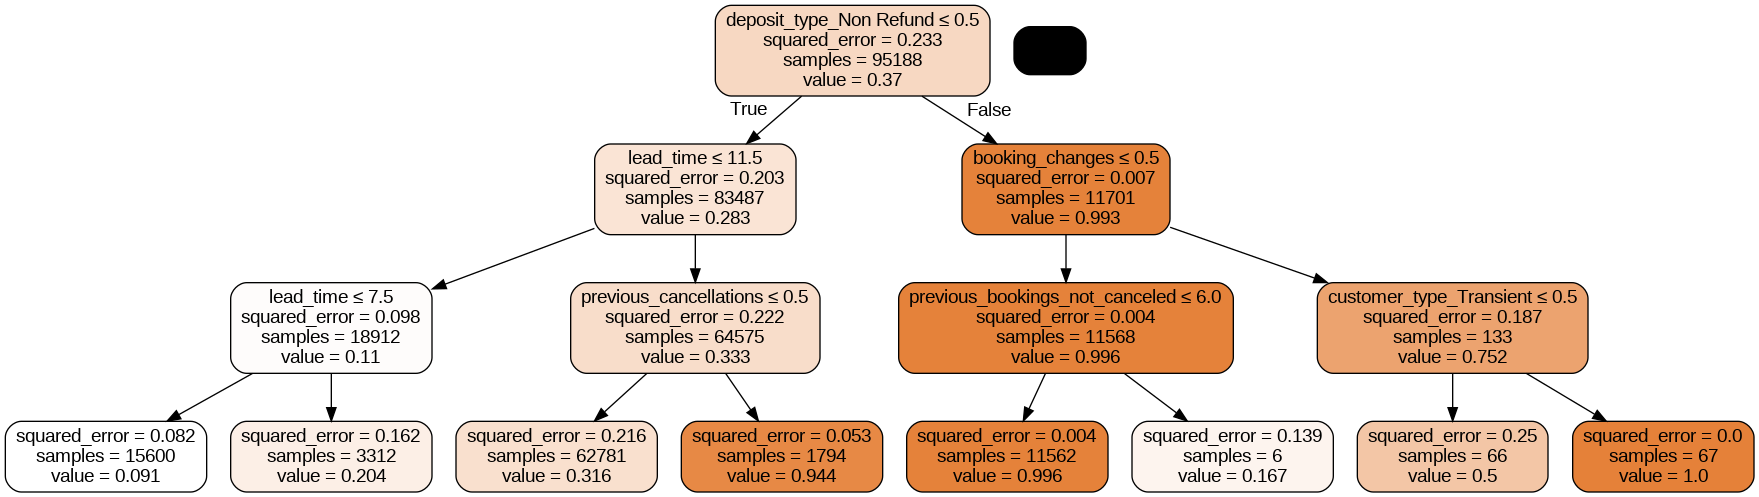

In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus as pplus
import pandas as pd # import pandas
import statsmodels.api as sm


from sklearn.model_selection import train_test_split

# Create a decision tree regressor
tree_regressor=DecisionTreeRegressor(max_depth=3, random_state=23)

# Fit the model
# Assuming X_train_selected contains the 4 features you want to use
tree_regressor.fit(X_train, y_train)  # Fit using X_train_selected

dot_data = StringIO()
# Get feature names from X_train_selected. If it's a pandas DataFrame:
feature_names = X_train.columns.tolist()


export_graphviz(tree_regressor, out_file=dot_data,
                feature_names=feature_names,  # Use the correct feature names
                filled=True, rounded=True,
                special_characters=True)
graph = pplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Prediction on Training data

In [ ]:

DT_predictions_tr = tree_regressor.predict(X_train[X_train.columns])

# Now calculate the RMSE
np.sqrt(np.square(DT_predictions_tr - y_train).mean())

0.404096097747392

In [ ]:

# Now you can call regressionSummary in your code:
regressionSummary(y_train, DT_predictions_tr)


Regression statistics

               Mean Error (ME) : -0.0000
Root Mean Squared Error (RMSE) : 0.4041
     Mean Absolute Error (MAE) : 0.3266


RMSE is not zero which means there is no overfitting issue

In [ ]:
cvparam = KFold(3, random_state=13, shuffle=True)
scores_mse_DT =  cross_validate(tree_regressor , X_train, y_train, \
                                cv=cvparam, scoring='neg_mean_squared_error')
scores_mse_DT['test_score']
np.sqrt(scores_mse_DT['test_score'].mean()*-1)

0.40472624120335693

**Interpretation:** Once we induce some variation in the training sample, by doing a 3-fold split, the accuracy of our decision tree-based prediction has been quite similar.

Prediction on Test data

In [ ]:

DT2_predictions_tt = tree_regressor.predict(X_test)
regressionSummary(y_test, DT2_predictions_tt)


Regression statistics

               Mean Error (ME) : 0.0039
Root Mean Squared Error (RMSE) : 0.4069
     Mean Absolute Error (MAE) : 0.3293


Interpretation: Our model is deviant from the actual values by about 4.061, on average when using the test data which is pretty good enough.

Ensemble model: Bagging, Boosting and Random Forest

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Bagging: Decide the parameters for the new Decision Tree with ensemble
DTreg_bag=RandomForestRegressor(max_features=10, random_state=23) # Bagging is special case of RF, when we use all features (3 in this case).

# Random forest: Decide the parameters for the new Decision Tree with ensemble
DTreg_RF=RandomForestRegressor(max_features=9, random_state=23)

# Boosting: Decide the parameters for the new Decision Tree with ensemble
DTreg_boost=GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=23) # Learning rate shrinks the contribution of each tree by learning_rate.

In [ ]:
# Fit the bagging model on training data
# Since we are using the training portion of the data, we are now "training" our model.
DTreg_bag.fit(X_train, y_train)

# Fit the random forest model on training data
# Since we are using the training portion of the data, we are now "training" our model.
DTreg_RF.fit(X_train, y_train)

# Fit the boosting model on training data
# Since we are using the training portion of the data, we are now "training" our model.
DTreg_boost.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=500, random_state=23)

In [ ]:
# Now, get the predicted values and evaluate the training of the new decision tree models:
DTbag_predictions_tr=DTreg_bag.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTRF_predictions_tr=DTreg_RF.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTboost_predictions_tr=DTreg_boost.predict(X_train) # predictions for training set

In [ ]:
# How good is this prediction of bagging in training?
regressionSummary(y_train, DTbag_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(y_train, DTRF_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(y_train,DTboost_predictions_tr)


Regression statistics

               Mean Error (ME) : -0.0020
Root Mean Squared Error (RMSE) : 0.1282
     Mean Absolute Error (MAE) : 0.0777

Regression statistics

               Mean Error (ME) : -0.0019
Root Mean Squared Error (RMSE) : 0.1283
     Mean Absolute Error (MAE) : 0.0780

Regression statistics

               Mean Error (ME) : 0.0000
Root Mean Squared Error (RMSE) : 0.3652
     Mean Absolute Error (MAE) : 0.2869


In [ ]:
# How good is the bagging model if subjected to variations in the training sample?
cvparam = KFold(3, random_state=13, shuffle=True)
scores_mse_DTbag = cross_validate(DTreg_bag, X_train, y_train, cv=cvparam, \
                                  scoring='neg_mean_squared_error')
scores_mse_DTbag['test_score']
np.sqrt(scores_mse_DTbag['test_score'].mean()*-1)

0.3207313246587909

                      feature  importance
42    deposit_type_Non Refund    0.150722
0                   lead_time    0.147002
14                        adr    0.100672
3   arrival_date_day_of_month    0.069584
16  total_of_special_requests    0.060913
2    arrival_date_week_number    0.060660
10     previous_cancellations    0.047148
17         number_of_bookings    0.042612
5        stays_in_week_nights    0.042180
1          arrival_date_month    0.032612


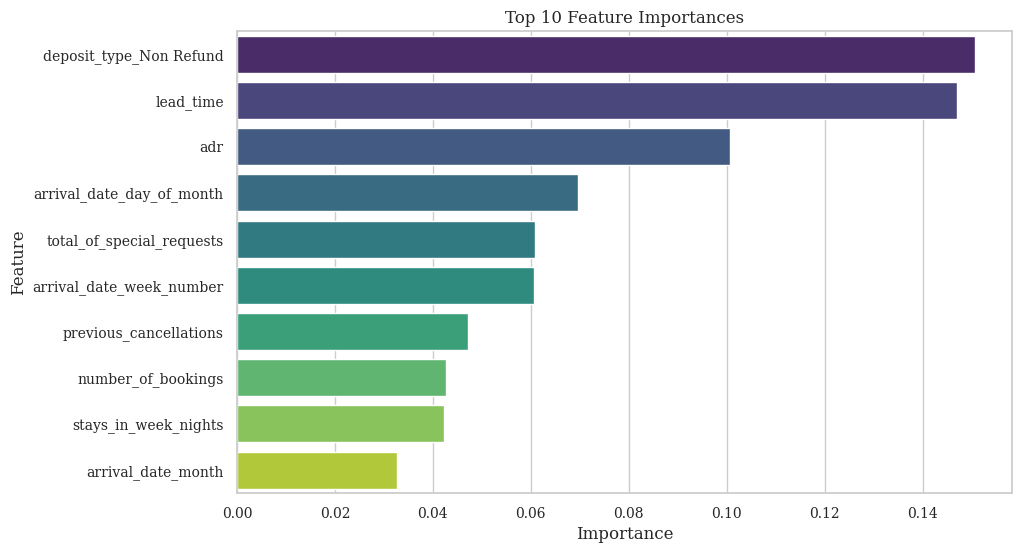

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances and create a DataFrame
importances = DTreg_bag.feature_importances_
feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False).head(10)  # Select top 10 features

# Print the top 10 features
print(feature_importances)

# Visualize the top 10 feature importances using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances, palette="viridis")
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# CLASSIFIER MODELS

Decision Tree Classifier

Decision Tree Classifier Evaluation:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     14917
           1       0.75      0.76      0.75      8880

    accuracy                           0.82     23797
   macro avg       0.80      0.80      0.80     23797
weighted avg       0.82      0.82      0.82     23797

Accuracy: 0.8155649871832584
ROC AUC: 0.8057925853385732


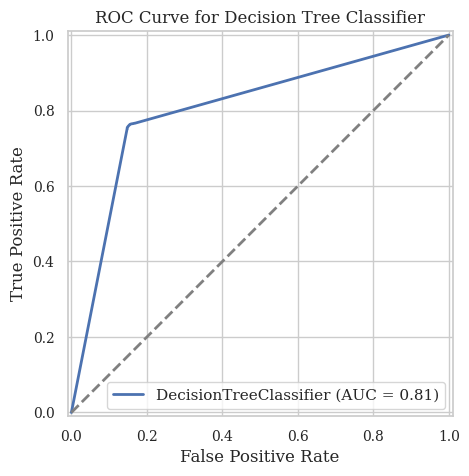

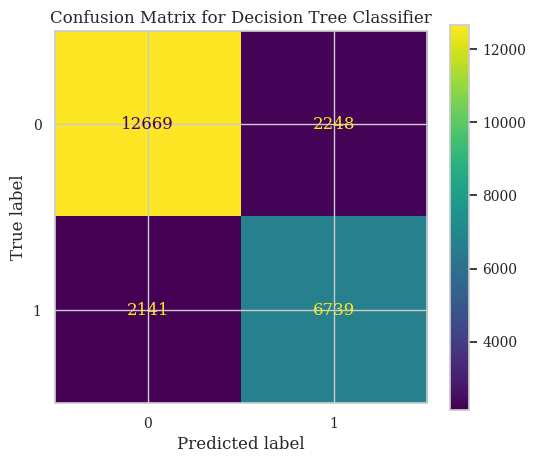

In [ ]:
# Initialize and train the decision tree classifier
dt_classifier = DecisionTreeClassifier(random_state=0)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the Decision Tree model
print("Decision Tree Classifier Evaluation:")
print(classification_report(y_test, y_pred_dt))
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt}")

# ROC Curve and AUC
roc_auc_dt = roc_auc_score(y_test, dt_classifier.predict_proba(X_test)[:, 1])
print(f"ROC AUC: {roc_auc_dt}")

RocCurveDisplay.from_estimator(dt_classifier, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve for Decision Tree Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(dt_classifier, X_test, y_test)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=0)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89     14917
           1       0.86      0.75      0.80      8880

    accuracy                           0.86     23797
   macro avg       0.86      0.84      0.85     23797
weighted avg       0.86      0.86      0.86     23797



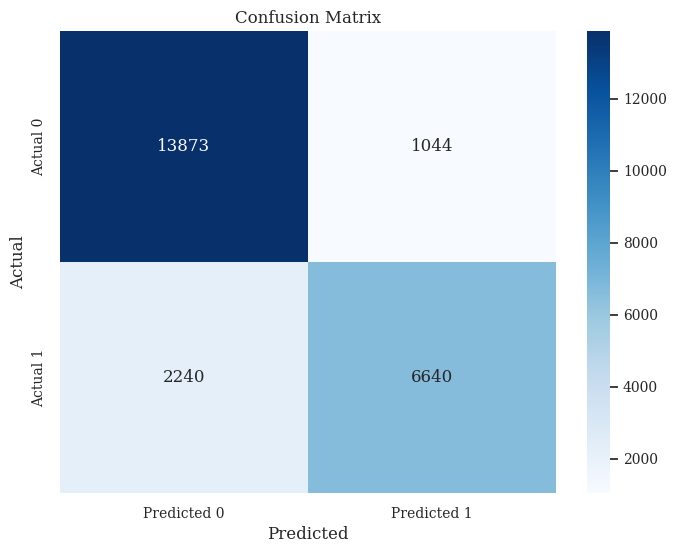

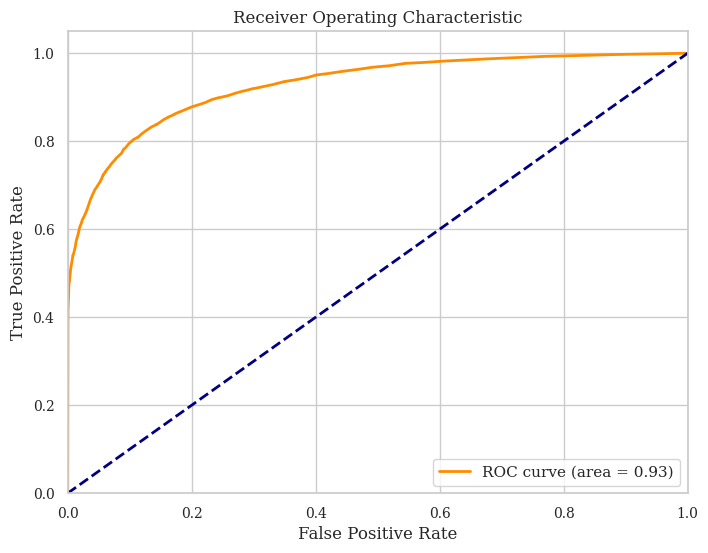

In [ ]:


from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y_test and y_pred_rf are already defined from previous code

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

XGboost Classifier

              precision    recall  f1-score   support

           0       0.84      0.93      0.88     14917
           1       0.85      0.70      0.77      8880

    accuracy                           0.84     23797
   macro avg       0.85      0.81      0.83     23797
weighted avg       0.84      0.84      0.84     23797



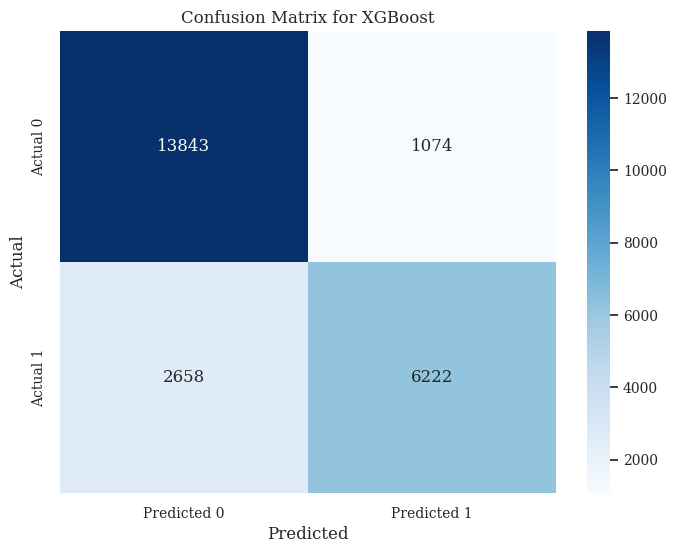

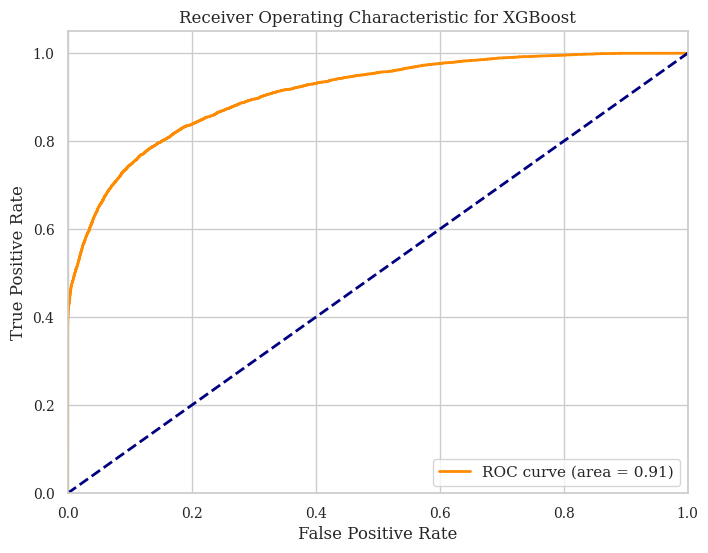

In [ ]:
# Initialize and train the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=0)
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
y_prob_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for XGBoost')
plt.legend(loc='lower right')
plt.show()

Ensemble Models

In [ ]:
# Import necessary libraries
from sklearn.ensemble import VotingClassifier, RandomForestClassifier  # Add RandomForestClassifier import
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, auc
from sklearn.metrics import accuracy_score
from io import StringIO
from sklearn.tree import export_graphviz
import pydotplus as pplus
from IPython.display import Image


# Initialize the classifiers
dt_classifier = DecisionTreeClassifier(random_state=0)
rf_classifier = RandomForestClassifier(random_state=0)
xgb_classifier = xgb.XGBClassifier(random_state=0)

# Create the ensemble model using VotingClassifier (soft voting)
ensemble_classifier = VotingClassifier(estimators=[
    ('dt', dt_classifier),
    ('rf', rf_classifier),
    ('xgb', xgb_classifier)
], voting='soft')  # Use soft voting for probabilistic predictions

# Train the ensemble model
ensemble_classifier.fit(X_train, y_train)



VotingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=0)),
                             ('rf', RandomForestClassifier(random_state=0)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=No...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=0, ...))],
                 voting='soft')

Ensemble Model Evaluation:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     14917
           1       0.81      0.75      0.78      8880

    accuracy                           0.84     23797
   macro avg       0.84      0.83      0.83     23797
weighted avg       0.84      0.84      0.84     23797

Accuracy: 0.8435096860948859
ROC AUC: 0.9201195413419722


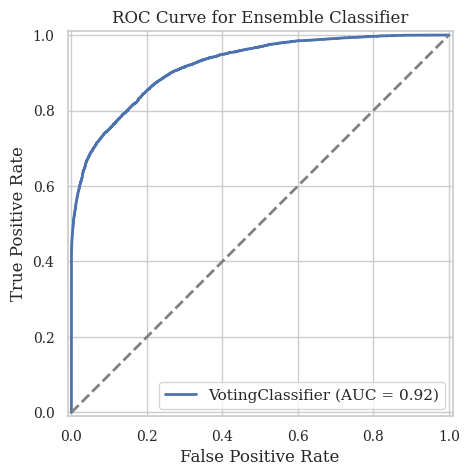

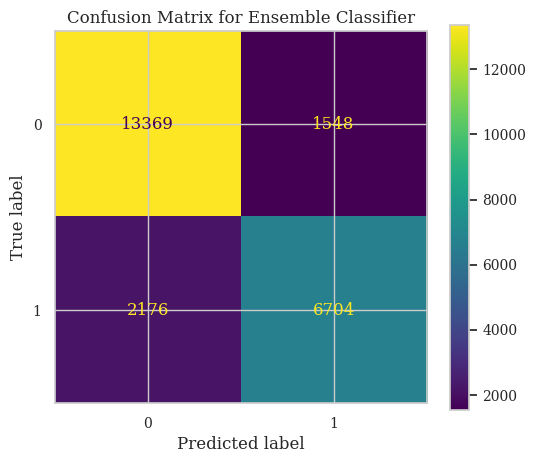

In [ ]:
# Make predictions on the test set using the ensemble model
y_pred_ensemble = ensemble_classifier.predict(X_test)

# Evaluate the ensemble model
print("Ensemble Model Evaluation:")
print(classification_report(y_test, y_pred_ensemble))
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"Accuracy: {accuracy_ensemble}")

# ROC Curve and AUC for the ensemble
roc_auc_ensemble = roc_auc_score(y_test, ensemble_classifier.predict_proba(X_test)[:, 1])
print(f"ROC AUC: {roc_auc_ensemble}")

RocCurveDisplay.from_estimator(ensemble_classifier, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve for Ensemble Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# Confusion Matrix for the ensemble
ConfusionMatrixDisplay.from_estimator(ensemble_classifier, X_test, y_test)
plt.title('Confusion Matrix for Ensemble Classifier')
plt.show()